The purpose of this file is to test various strategies and algorithms. Each one will do paper-trading by using past performance of various ETFs and companies as the trading field, using data from 2000 to 2025 (25 years). The purpose of this file is to try and discover an effective strategy before implementing it in the real world.

**Data Gathering**

First, gather all of the data of various tickers, and store them in .csv files in a data folder so that they can be later loaded using pandas. Doing this seperately allows us to only run the data gathering part once, only having to do so again if we change which tickers we want to test with, or if we need to update the data range. The data will be gahtered from yahoo finance.

In [15]:
# Initial Imports
import yfinance as yf
import os

In [22]:
# The tickers to use.
tickers = ["AAPL", "GOOG", "KOD", "MDB", "NVDA", "SGLN", "SPY"]

In [20]:
# Make sure that the data folder exists.
if not os.path.isdir("data"):
    os.mkdir("data")

In [21]:
# Downloading and saving tickers.
for ticker in tickers:
    try:
        data = yf.download(ticker, start="2000-01-01", end="2025-12-31")
        data.to_csv(f"data/{ticker}.csv")
        print(f"Downloaded {ticker}.")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded AAPL.
Downloaded GOOG.
Downloaded KOD.
Downloaded MDB.



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded NVDA.
Downloaded SGLN.
Downloaded SPY.


**Simulation Construction**

Now that we have the data, we'll build a class that we can use for constructing a simulation. The simulation will simply go through each point in time, adjusting stocks, prices, and overall portfolio value with each step through time. Each step will also return the total portfolio value at the end of that time step, allowing us to eventually visualise it as a graph.

In [97]:
# Initial Imports
import pandas as pd
from datetime import date, timedelta

In [150]:
# First, load the data into a "Data" class.
# Once again, we use a seperate class so that we don't have to re-run the code every time.

class Data:
    def __init__(self):
        self.data = {}

        for ticker in tickers:
            data = pd.read_csv(f"data/{ticker}.csv", parse_dates = True)

            # The first two rows have garbage data, so we can ignore them.
            data = data[2:].reset_index(drop = True)
            data = data.rename(columns={"Price": "Date"})

            self.data[ticker] = data

    def recieve_ticker_info(self, ticker, date):
        index = date.strftime("%Y-%m-%d")
        dataObject = self.data[ticker]

        foundValues = dataObject[dataObject["Date"] == index]

        if len(foundValues) <= 0:
            return None

        foundValues = foundValues.iloc[0]

        return {
            "OPEN": float(foundValues["Open"]),
            "LOW": float(foundValues["Low"]),
            "HIGH": float(foundValues["High"]),
            "CLOSE": float(foundValues["Close"]),
            "VOLUME": float(foundValues["Volume"])
        }

dataObject = Data() # Will be passed into every Simulation instance we make.

In [366]:
# The Simulation class will represent a single instance of a portfolio, allowing us to simulate growth.

class Simulation:
    def __init__(self, dataObject, startingValue = 1000):
        self.dataObject = dataObject
        self.tickers = list(self.dataObject.data.keys())
        
        self.baseStockInfo = {}
        self.currentStockInfo = {}
        
        self.looseCash = startingValue
        self.heldStocks = {}

        self.currentDate = date(2000, 1, 1)
        self.portfolioWorth = []

        self.generate_data()

    def generate_data(self):
        self.currentStockInfo = {}
        
        for ticker in self.tickers:
            data = self.dataObject.recieve_ticker_info(ticker, self.currentDate)

            if data != None:
                self.baseStockInfo[ticker] = data

            self.currentStockInfo[ticker] = data

    def buy_stocks(self, ticker, amount):
        if not ticker in self.currentStockInfo or self.currentStockInfo[ticker] == None:
            return

        amount = min(amount, self.looseCash)

        if not ticker in self.heldStocks:
            self.heldStocks[ticker] = 0

        self.heldStocks[ticker] += amount / self.currentStockInfo[ticker]["OPEN"]
        self.looseCash -= amount

    def sell_stocks(self, ticker, amount):
        if not ticker in self.baseStockInfo or self.baseStockInfo[ticker] == None or not ticker in self.heldStocks:
            return

        amount = (max(0, min(100, amount)) / 100) * self.heldStocks[ticker]
        self.looseCash += amount * self.baseStockInfo[ticker]["OPEN"]
        self.heldStocks[ticker] -= amount
        

    def get_portfolio_value(self):
        value = self.looseCash

        for stock in self.heldStocks.keys():
            if not stock in self.baseStockInfo or not stock in self.heldStocks:
                continue

            value += self.heldStocks[stock] * self.baseStockInfo[stock]["CLOSE"]

        return value

    def advance_day(self):
        value = self.get_portfolio_value()
        self.portfolioWorth.append(value)
        self.currentDate += timedelta(days = 1)
        self.generate_data()

    
    def simulate(self, strategy):
        while self.currentDate < date(2025, 12, 31):
            strategy.use_strategy(self)
            self.advance_day()

In [312]:
# Last, the Strategy class defines what to do at each moment, using current stock info as a teller.
class Strategy:
    def __init__(self):
        pass

    def use_strategy(self, simulation):
        pass

**Displaying Results**

We'll use matplotlib and numpy together to display the final results of our strategies all on the same graph, making it easier to tell how they performed when put against each other, and which one performed the best.

In [319]:
# Initial imports.
import matplotlib.pyplot as plt

In [352]:
def display_performances(simulations):
    for simulation in simulations.keys():
        values = simulations[simulation].portfolioWorth
        plt.plot(values, label = simulation)

    plt.legend(loc = "upper left")
    plt.grid(True)
    plt.show()

**Initial Setup**

The main strategy that most people rely on is the "Buy & Hold" strategy, where you simply keep buying into stocks and not let go of them no matter what. We'll build and test both this strategy and also just not buying anything as a control.

For reference, each simulation will assume that we have £1,000 to start with, and are adding £10 every day (so about £300 every month).

In [424]:
# This new simulation will simply have that 1000 pound start, along with the +£10 every day.
class Test_Simulation(Simulation):
    def __init__(self, dataObject):
        super().__init__(dataObject, 1000)

    def advance_day(self):
        super().advance_day()
        self.looseCash += 10

In [425]:
"""
Strategy #1 - Control Strategy.

The control for the simulation just to see what would happen if we did absolutely nothing.
"""

class Control_Strategy(Strategy):
    def use_strategy(self, simulation):
        pass

In [428]:
"""
Strategy #2 - Buy & Hold.

Every time we have loose cash, we'll evenly buy into each and every stock and hold them. We'll never sell, either.
"""

class Buy_And_Hold_Strategy(Strategy):
    def use_strategy(self, simulation):
        availableTickers = []

        for ticker in simulation.currentStockInfo.keys():
            if simulation.currentStockInfo[ticker] != None:
                availableTickers.append(ticker)
        
        if len(availableTickers) <= 0:
            return
        
        toSpend = simulation.looseCash / len(availableTickers)

        for ticker in availableTickers:
            simulation.buy_stocks(ticker, toSpend)

In [429]:
# Simulate both strategies.
strategies = {
    "Control": Control_Strategy(),
    "Buy And Hold": Buy_And_Hold_Strategy()
}

simulations = {}

for strategy in strategies.keys():
    newSim = Test_Simulation(dataObject)
    newSim.simulate(strategies[strategy])
    simulations[strategy] = newSim

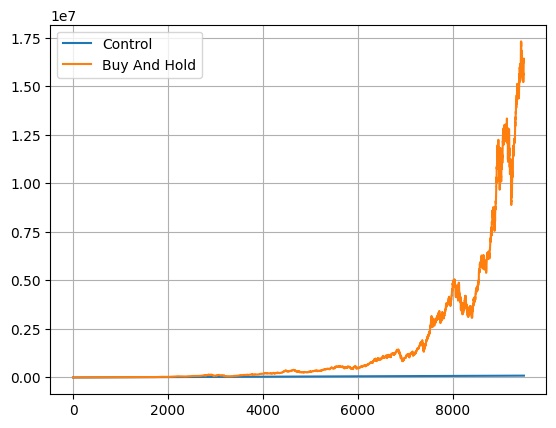

In [430]:
display_performances(simulations)